# SNP data and *mapper* / SNP 데이터와 *mapper*

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans Mono'
from plotly.subplots import make_subplots
from scipy.stats import entropy
from data import load_data

df = load_data()
fd = df.transpose().iloc[3:]

base_freq = np.zeros((df.shape[1]-3, 4))
for num, (name, col) in enumerate(df.iloc[:, 3:].items()):
    base_freq[num, 0] = col.str.count('A').sum()
    base_freq[num, 1] = col.str.count('C').sum()
    base_freq[num, 2] = col.str.count('G').sum()
    base_freq[num, 3] = col.str.count('T').sum()
base_freq_rel = base_freq / np.sum(base_freq, axis=1, keepdims=True)

mask_AC = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [0, 1], axis=1)
mask_CA = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [1, 0], axis=1)
mask_AG = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [0, 2], axis=1)
mask_GA = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [2, 0], axis=1)
mask_CT = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [1, 3], axis=1)
mask_TC = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [3, 1], axis=1)
mask_GT = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [2, 3], axis=1)
mask_TG = np.all(np.argsort(base_freq, axis=1)[:, 2:] == [3, 2], axis=1)

mask_AC_CA = mask_AC | mask_CA
mask_AG_GA = mask_AG | mask_GA
mask_CT_TC = mask_CT | mask_TC
mask_GT_TG = mask_GT | mask_TG

loci_entropy = df.iloc[:, 3:].apply(lambda s: entropy(s.value_counts()))

## 샘플들(사람들)간의 거리를 측정한다

In [26]:
import itertools

dist_d = np.zeros((df.shape[0], df.shape[0]))
for i in range(df.shape[0]):
    dist_d[i] = (df.iloc[i, 3:] != df.iloc[:, 3:]).sum(axis=1)

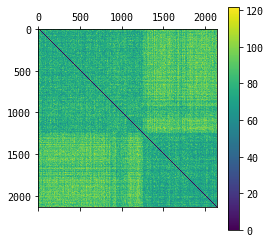

In [27]:
plt.colorbar(plt.matshow(dist_d))

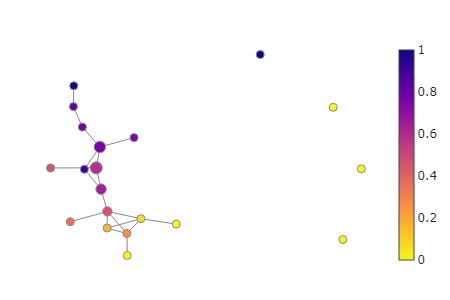

In [65]:
from gtda.mapper import CubicalCover, Projection, Eccentricity, Entropy, make_mapper_pipeline, plot_static_mapper_graph
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.pipeline import make_union
# from umap import UMAP


# umap = UMAP(random_state=42)

mask = df['Geographic region'] != 'SWA'

pipe = make_mapper_pipeline(
    filter_func=make_union(
        Eccentricity(
            exponent=2,
            metric='precomputed'
        ),
        Entropy(),
    ),
    cover=CubicalCover(n_intervals=8, overlap_frac=0.031),
    clusterer=DBSCAN(
        metric='precomputed'
    ),
)

for num, pop in enumerate(df.loc[mask, 'POP-ID'].unique()):
    fig = plot_static_mapper_graph(
        pipe, 
        dist_d[mask][:, mask],
        # color_data=np.zeros_like(df.loc[mask,'POP-ID']==pop),
        color_data=(df.loc[mask,'Geographic region']=='NEA'),
        plotly_params={
            'node_trace': {'marker_colorscale': 'plasma_r'},
            # 'layout': {'title': pop}
        }
    )
    fig.show(renderer='png', width=450, height=300)
    # fig.show()
    fig.close()
    break

## 특성들(rs####)간의 거리를 측정한다

In [31]:
import itertools

dist_f = np.zeros((fd.shape[0], fd.shape[0]))
for i, j in itertools.combinations(range(fd.shape[0]), 2):
    dist_f[i, j] = (fd.iloc[i] != fd.iloc[j]).mean()
    dist_f[j, i] = dist_f[i, j]


각 특성은 발견되는 염기에 따라 크게 네 가지(A&C, A&G, C&T, G&T)로 구분된다.

이들을 한꺼번에 분석하면 intra 관계보다 inter관계가 부각되어 재미가 없습니다. 

그러므로 당신은 표본으로서 C&T만 관찰하기를 바랄 것이다.

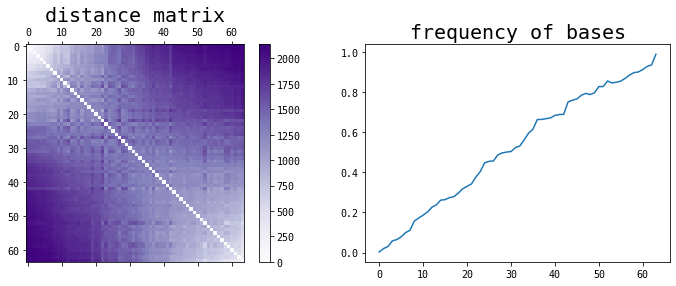

In [6]:
mask = mask_CT_TC
# mask = (base_freq_rel[:, 1] > 0.3) & (base_freq_rel[:, 3] > 0.3)

sorter = np.argsort(base_freq[mask, 3])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
# plt.gca().matshow(dist_mat[mask][:, mask][sorter][:, sorter])
plt.colorbar(
    plt.gca().matshow(dist_f[mask][:, mask][sorter][:, sorter], cmap='Purples')
)
plt.title('distance matrix', fontsize=20)

plt.subplot(1, 2, 2)
plt.gca().plot(base_freq_rel[mask_CT_TC, 3][sorter])
plt.title('frequency of bases', fontsize=20)

plt.show(); plt.close()

여러 특성들을 블렌딩하는 것은 집단의 동등변량 행동에 의해 보장됩니다

In [ ]:
import itertools

base3coded_permuted = np.zeros((24, fd.shape[0], fd.shape[1]))
for num_order, order in enumerate(itertools.permutations('ACGT')):
    for num_row, (_, row) in enumerate(fd.iterrows()):
        for base in 'ACGT':
            base3coded_permuted[num_order, num_row] += row.str.count(base) * (3**order.index(base))

dist_q = np.zeros((fd.shape[0], fd.shape[0]))
for i, j in np.ndindex(dist_q.shape):
    if i >= j: continue
    dist_q[i, j] = np.min(np.mean(base3coded_permuted[0, i] != base3coded_permuted[:, j], axis=-1))
    dist_q[j, i] = dist_q[i, j]

여러 시각화 방법을 동원한다 첫째로 차원 감소를 탐구합니다.

그러나 *mapper*가 보여주는 풍경은 사뭇 다릅니다.

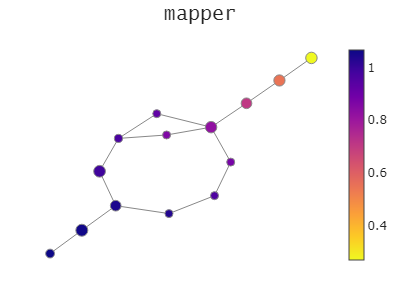

In [79]:
from gtda.mapper import CubicalCover, Projection, Eccentricity, Entropy, make_mapper_pipeline, plot_static_mapper_graph
from sklearn.cluster import DBSCAN
from sklearn.pipeline import make_union

pipe = make_mapper_pipeline(
    filter_func=make_union(
        Eccentricity(
            exponent=2,
            metric='precomputed'
        ),
        # Entropy(),  # not used for ALL
    ),
    # cover=CubicalCover(n_intervals=5, overlap_frac=0.22),

    # cover=CubicalCover(n_intervals=6, overlap_frac=0.27), # for AG
    # cover=CubicalCover(n_intervals=7, overlap_frac=0.28), # for CT
    cover=CubicalCover(n_intervals=10, overlap_frac=0.25),  # for ALL
    clusterer=DBSCAN(
        metric='precomputed'
    ),
)
fig = plot_static_mapper_graph(
    pipe, 
    # dist_f[mask_AG_GA][:, mask_AG_GA],
    # color_data=base_freq_rel[mask_AG_GA, 0],
    # dist_f[mask_CT_TC][:, mask_CT_TC],  # for CT
    # color_data=base_freq_rel[mask_CT_TC, 3],  # for CT
    dist_q,  # for ALL
    color_data=loci_entropy,  # for ALL
    plotly_params={
        'node_trace': {'marker_colorscale': 'plasma_r'},
        'layout': {
            'title': 'mapper', 
            'title_font_family': 'Lucida Sans Typewriter', 
            'title_font_size': 20,
            'title_x': 0.5
            }
        }
)
fig.show(renderer='png', width=400, height=300)
fig.close()

c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\umap\umap_.py:1780: UserWarning:

using precomputed metric; inverse_transform will be unavailable



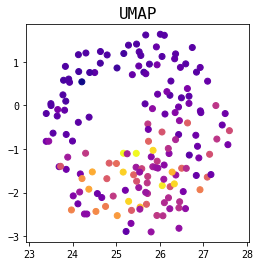

c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\manifold\_t_sne.py:691: FutureWarning:

'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.



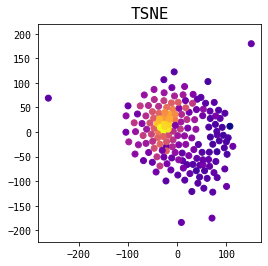

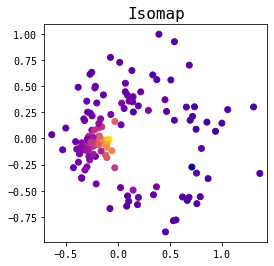

In [93]:
from sklearn.manifold import TSNE, Isomap
from umap import UMAP

for reducer_name, reducer in [
    ('UMAP', UMAP(
        random_state=42,
        metric='precomputed'
    )),
    ('TSNE', TSNE(
        n_components=2,
        metric='precomputed',
        # square_distances='legacy',
        random_state=42
    )),
    ('Isomap', Isomap(n_components=2, metric='precomputed'))
]:
    plt.figure(figsize=(4, 4))
    plt.scatter(
        # *reducer.fit_transform(dist_f[mask_AG_GA][:, mask_AG_GA]).T,
        # c=base_freq_rel[mask_AG_GA, 0],
    #     *reducer.fit_transform(dist_f[mask_CT_TC][:, mask_CT_TC]).T,
    #     c=base_freq_rel[mask_CT_TC, 3]
        *reducer.fit_transform(dist_q).T,
        c=loci_entropy,
        cmap='plasma_r'
    )
    plt.axis('equal')
    plt.title(reducer_name, fontsize=16)
    # if reducer_name == 'TSNE': plt.xlim(-125, 125); plt.ylim(-125, 125)
    plt.show(); plt.close()

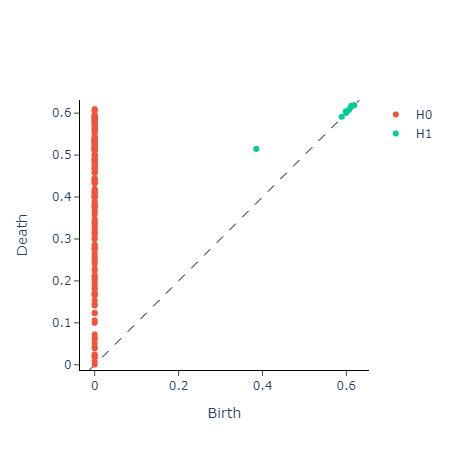

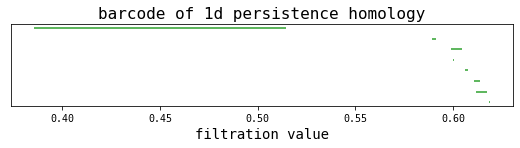

In [80]:
from gtda.homology import VietorisRipsPersistence

def code_integer(x):
    return x.str.count('T') + x.str.count('G')
# pershom = VietorisRipsPersistence(homology_dimensions=(0, 1, 2), metric='hamming')
# Xt = pershom.fit_transform(fd[mask_AG_GA].apply(code_integer).values[np.newaxis],)
# Xt = pershom.fit_transform(fd[mask_CT_TC].apply(code_integer).values[np.newaxis],)

pershom = VietorisRipsPersistence(metric='precomputed')
Xt = pershom.fit_transform(dist_q[np.newaxis])

fig = pershom.plot(Xt)
fig.show(renderer='png', width=450, height=450)


plt.figure(figsize=(9, 1.5))
for num, bar in enumerate(Xt[Xt[..., -1] == 1]):
    plt.hlines(y=num, xmin=bar[0], xmax=bar[1], color='C2')
# plt.xlim(0, )
plt.yticks([])
# plt.ylabel('holes', fontsize=14)
plt.xlabel('filtration value', fontsize=14)
plt.title('barcode of 1d persistence homology', fontsize=16)
plt.show(); plt.close()